In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm
from utils import rnmse
from torch.utils.data import DataLoader, TensorDataset
from sklearn.base import BaseEstimator
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Subset
from skorch import NeuralNet
from neuralop import FNO
import pandas as pd
import seaborn as sns
import matplotlib
sns.set_style('whitegrid')
sns.set_context('notebook')
sns.set_palette('hot', n_colors=7)
#plt.rc('text', usetex=True)

font = {'family' : 'serif',
        'weight' : 'bold',
        'size'   : 22}

matplotlib.rc('font', **font)

plt.rc('xtick',labelsize=12)
plt.rc('ytick',labelsize=12)

X = torch.cat([torch.load("../dataset/x_train.pt"), torch.load("../dataset/x_train_2.pt")])
y = torch.cat([torch.load("../dataset/y_train.pt"), torch.load("../dataset/y_train_2.pt")])
c = torch.cat([torch.load("../dataset/c_train.pt"), torch.load("../dataset/c_train_2.pt")])

X_test = torch.load("../dataset/x_test.pt")
y_test = torch.load("../dataset/y_test.pt")
c_test = torch.load("../dataset/c_test.pt")

def scorer_rnmse(estimator, x, y):
    return rnmse(estimator.predict(x), y)

scores = {}

class CNN(nn.Module):
    def __init__(self, input_dim=(X.shape[1:]), output_dim=(y.shape[1:])):
        super().__init__()

        self.features = nn.Sequential(
            nn.Dropout(0.1),
            nn.Conv2d(1, 8, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.Conv2d(32, 16, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.Conv2d(16, 8, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.Conv2d(8, 1, kernel_size=3, padding='same'),
        )
        
    def forward(self, x):
        return self.features(x)

device = 'cuda'

def get_rnmse():
    return rnmse

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [120]:
import torch.nn.functional as F

def laplacian_2d(x, dx=1.0):
    kernel = torch.tensor([[[
            [ 0,   0,  -1,   0,  0],
            [ 0,   0,  16,   0,  0],
            [-1,  16, -60,  16, -1],
            [ 0,   0,  16,   0,  0],
            [ 0,   0,  -1,   0,  0],
        ]]],
        device=x.device, dtype=x.dtype
    )/ (12.0 * dx**2)
    x_padded = F.pad(x, pad=(2, 2, 2, 2), mode='circular')
    lap = F.conv2d(x_padded, kernel, padding=0)
    return lap.squeeze(1)

def loss_fn(u_prev, u_curr, u_pred, c, dt=0.001, dx=1.0):
    u_tt = (u_pred - 2.0 * (u_curr) + u_prev) / (dt ** 2)
    lap_u = laplacian_2d(u_curr, dx=dx)
    c2 = c ** 2
    R = u_tt - c2 * lap_u
    return torch.abs(R).mean()

In [121]:
from utils import ricker

def init(nx, nt, dt):
    isx = 1
    isz = nx // 2
    f0  = 15 * 5
    
    t = torch.arange(1, nt+1, device=device) * dt
    T0 = 1.0 / (15 * 5)

    tmp = torch.diff(torch.tensor(ricker(dt, T0), device=device, dtype=torch.float32)) * 1e7
    src = torch.zeros(nt, device=device, dtype=torch.float32)
    src[:tmp.numel()] = tmp

    lam = c * T0
    
    x = torch.arange(nx, device=device) * dx
    z = x.clone()

    sigma = 1.5 * dx
    x0, z0 = x[isx], z[isz]

    xx = x[:, None]
    zz = z[None, :]

    sg = torch.exp(-((xx - x0)**2 + (zz - z0)**2) / sigma**2)
    sg = sg / sg.max()

    return (src, sg)

In [122]:
n_points = X.shape[0]
n_cv = 5
n_epochs = 50
nx = X.shape[2]
nt = X.shape[1]
dt = 0.001
dx = 1.0
batch_size = 32

In [124]:
model = CNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=5e-4)
loss_fn = loss_fn

In [ ]:
model.train()
for _ in (pbar:=tqdm(range(n_epochs))):
    src, sg = init(nx, nt, dt)
    src, sg = src.to(device), sg.to(device)
    src /= (.5*src.max())
    c = torch.ones((batch_size, 1, nx, nx)).to(device)
    u_prev = 0.01*(torch.rand((batch_size, 1, nx, nx))-0.5).to(device) + sg * src[0] * dt**2
    u_curr = model(u_prev) + sg * src[1] * dt**2
    for i in range(2, nt):
        optimizer.zero_grad()
        u_next = model(u_curr)
        loss = loss_fn(u_prev, u_curr, u_next, c)
        loss.backward()
        u_next += sg * src[i] * dt**2
        pbar.set_description(f"Loss: {loss.item():.5f}")
        optimizer.step()
        u_prev, u_curr = u_curr.detach(), u_next.detach()
torch.cuda.empty_cache()

  0%|          | 0/50 [00:00<?, ?it/s]

In [118]:
obs = []

src, sg = init(nx, nt, dt)
src, sg = src.to(device), sg.to(device)
u_prev = 0.01*(torch.rand((1, 1, nx, nx))-0.5).to(device) + sg * src[0] * dt**2
u_curr = model(u_prev) + sg * src[1] * dt**2
for i in range(2, nt):
    u_next = model(u_curr) + sg * src[i] * dt**2
    obs.append(u_next.squeeze()[0].detach().cpu())
    u_prev, u_curr = u_curr.detach(), u_next.detach()

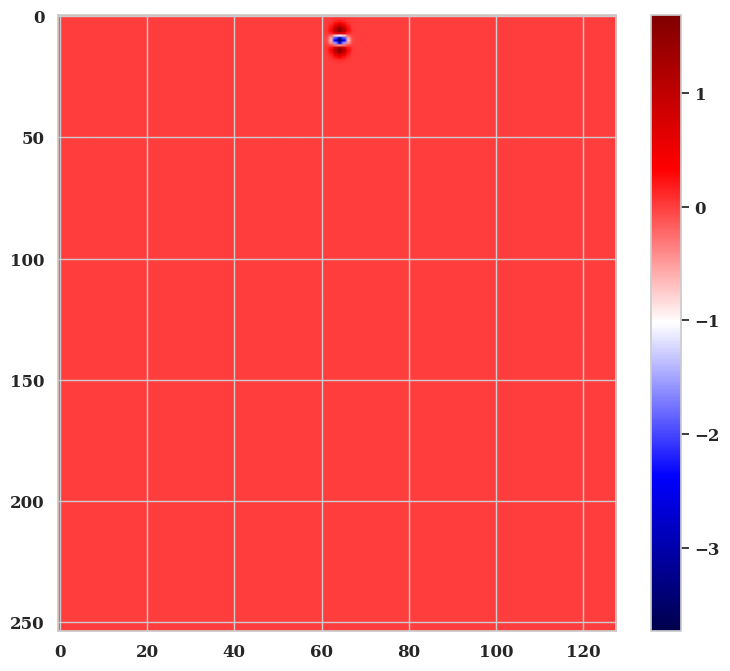

In [119]:
plt.figure(figsize=(9, 8))
plt.imshow(torch.stack(obs), aspect='auto', cmap='seismic')
plt.colorbar()
plt.show()